In [1]:
from sklearn.datasets import load_diabetes
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Lasso
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split


In [2]:
data=load_diabetes()
df=pd.DataFrame(data.data,columns=data.feature_names)
df['TARGET']=data.target
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,TARGET
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [3]:
X_train,X_test,y_train,y_test=train_test_split(data.data,data.target,test_size=0.2,random_state=2)


In [4]:
from sklearn.linear_model import Lasso
from sklearn.metrics import r2_score

coefs = []
r2_scores = []   # correct name

for i in [0, 0.1, 1, 10]:
    reg = Lasso(alpha=i)
    reg.fit(X_train, y_train)
    
    coefs.append(reg.coef_.tolist())
    
    y_pred = reg.predict(X_test)
    r2_scores.append(r2_score(y_test, y_pred))

c:\Users\HP\anaconda3\Lib\site-packages\sklearn\base.py:1473: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
c:\Users\HP\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:697: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
c:\Users\HP\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.967e+05, tolerance: 2.124e+02 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent

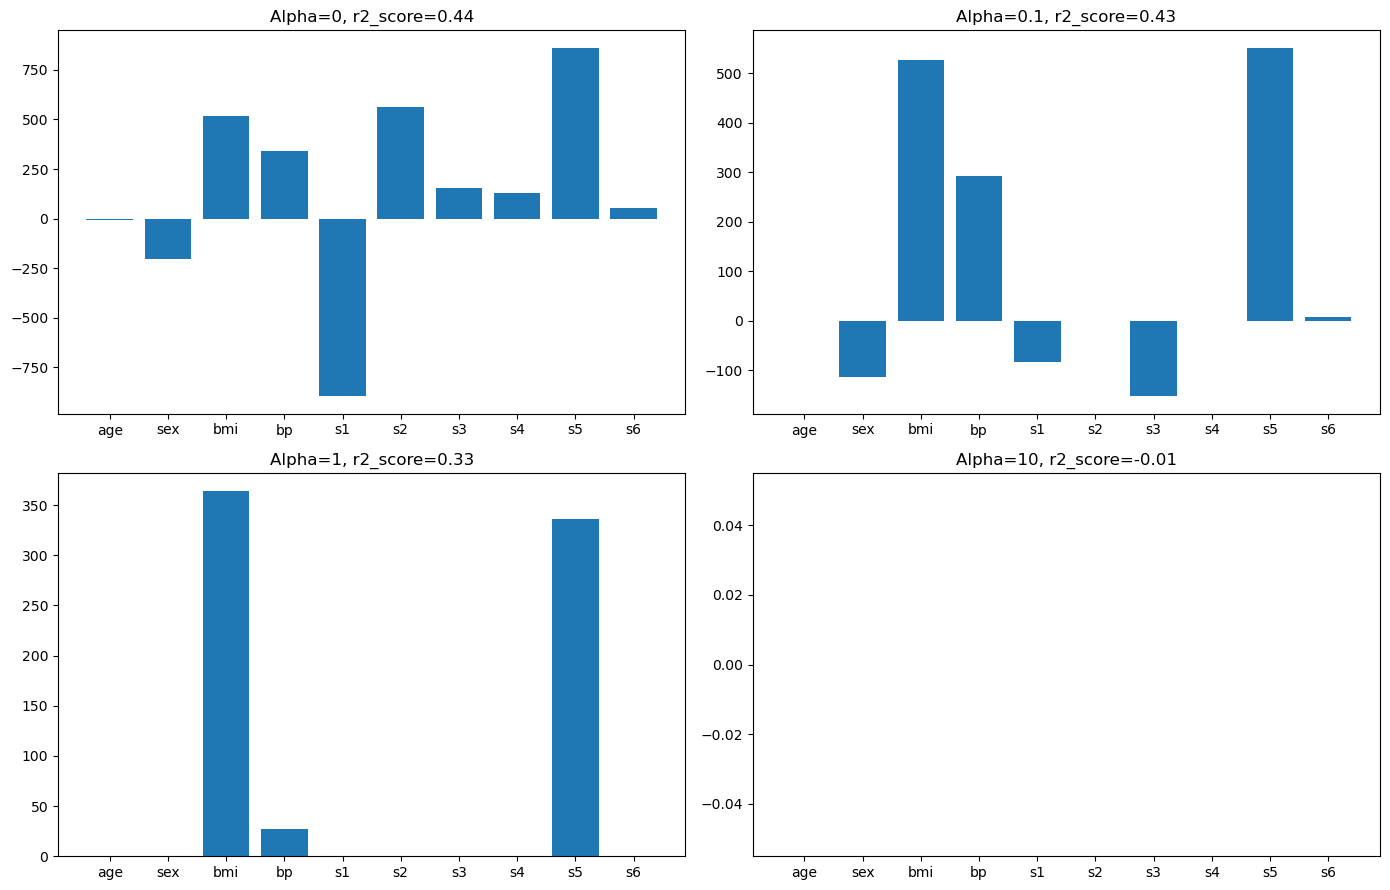

In [6]:
plt.figure(figsize=(14, 9))

plt.subplot(221)
plt.bar(data.feature_names, coefs[0])
plt.title('Alpha=0, r2_score={}'.format(round(r2_scores[0], 2)))

plt.subplot(222)
plt.bar(data.feature_names, coefs[1])
plt.title('Alpha=0.1, r2_score={}'.format(round(r2_scores[1], 2)))

plt.subplot(223)
plt.bar(data.feature_names, coefs[2])
plt.title('Alpha=1, r2_score={}'.format(round(r2_scores[2], 2)))

plt.subplot(224)
plt.bar(data.feature_names, coefs[3])
plt.title('Alpha=10, r2_score={}'.format(round(r2_scores[3], 2)))

plt.tight_layout()
plt.show()